# Customer Churn Analysis (Telecom)

**Business question:** Which customers are leaving, why, and what should the company do to keep them?

**Dataset:** Telco Customer Churn (IBM sample data, ~7,000 customers, 21 columns; `Churn` = Yes/No)
**Tools:** Python, pandas, Matplotlib (scikit-learn for the optional model at the end)

**Plan:** load data, clean it, measure the overall churn rate, compare churn across customer groups, find the highest-risk segment, estimate revenue at risk, then write recommendations.

## Step 1: Load the data
Upload `WA_Fn-UseC_-Telco-Customer-Churn.csv` to Colab (left sidebar > Files > Upload), then run this cell.
*Why:* we need the data in a pandas DataFrame, which is a table we can filter, group, and summarize.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: First look at the data
*Why:* before analysis, check the size, column types, and whether the target column (`Churn`) is balanced.

In [3]:
print('Rows, columns:', df.shape)
print()
df.info()
print()
print(df['Churn'].value_counts())

Rows, columns: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

## Step 3: Clean the data
Real data has problems. We check for them and fix them, and note every change.
* `TotalCharges` is stored as text because a few rows contain a blank space, so we convert it to a number.
* Rows with no `TotalCharges` are brand-new customers (tenure = 0) who have not been billed yet, so we drop them (very few rows).
* We also check for duplicate customers.

In [4]:
# 1. Convert TotalCharges to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges before:', df['TotalCharges'].isnull().sum())

# 2. These rows are new customers with tenure 0 (not billed yet): drop them
before = len(df)
df = df.dropna(subset=['TotalCharges'])
print('Rows dropped:', before - len(df))

# 3. Duplicate customers?
print('Duplicate customer IDs:', df['customerID'].duplicated().sum())

# 4. SeniorCitizen is 0/1; make it Yes/No so it reads like the other columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 5. Helper column: Churn as 1/0 so we can average it into a churn rate
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

print('Clean shape:', df.shape)

Missing TotalCharges before: 11
Rows dropped: 11
Duplicate customer IDs: 0
Clean shape: (7032, 22)


## Step 4: Overall churn rate
*Why:* this is the baseline. Every group we look at next is compared against it.

Overall churn rate: 26.6%


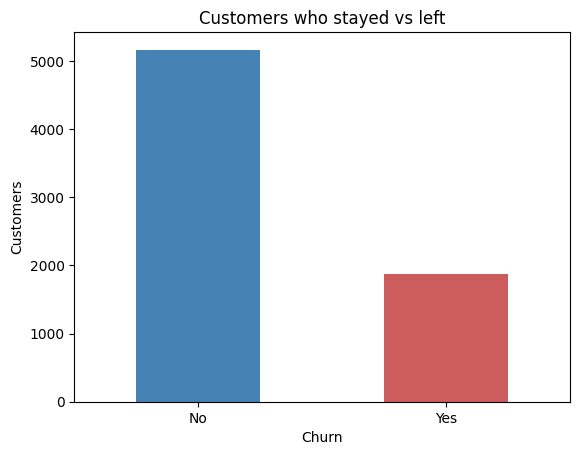

In [5]:
overall_churn = df['ChurnFlag'].mean() * 100
print(f'Overall churn rate: {overall_churn:.1f}%')

df['Churn'].value_counts().plot.bar(color=['steelblue', 'indianred'])
plt.title('Customers who stayed vs left')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.show()

## Step 5: Churn rate by customer group
We build one reusable function: for any column, it shows the percentage of customers in each group who churned.
*Why:* a group whose churn rate is far above the overall rate is a problem area.

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64


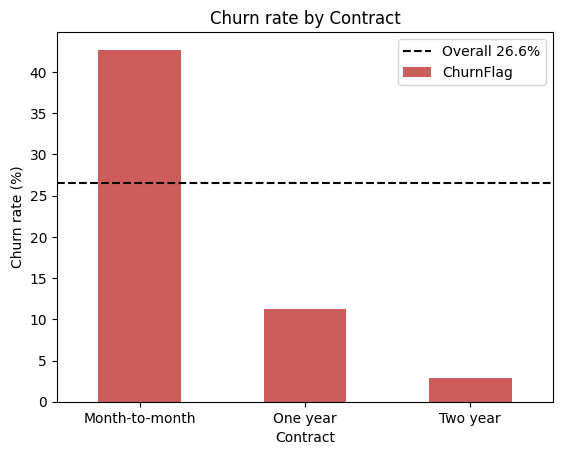

In [6]:
def churn_by(col, rotate=0):
    rate = (df.groupby(col)['ChurnFlag'].mean() * 100).sort_values(ascending=False)
    print(rate.round(1))
    rate.plot.bar(color='indianred')
    plt.axhline(overall_churn, color='black', linestyle='--', label=f'Overall {overall_churn:.1f}%')
    plt.title(f'Churn rate by {col}')
    plt.ylabel('Churn rate (%)')
    plt.xticks(rotation=rotate)
    plt.legend()
    plt.show()

churn_by('Contract')

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: ChurnFlag, dtype: float64


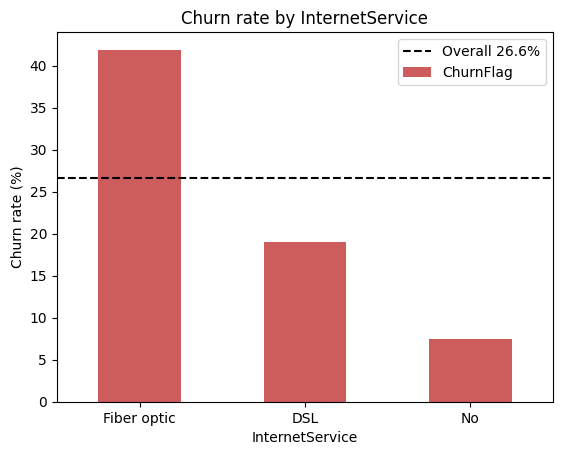

In [7]:
churn_by('InternetService')

PaymentMethod
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Name: ChurnFlag, dtype: float64


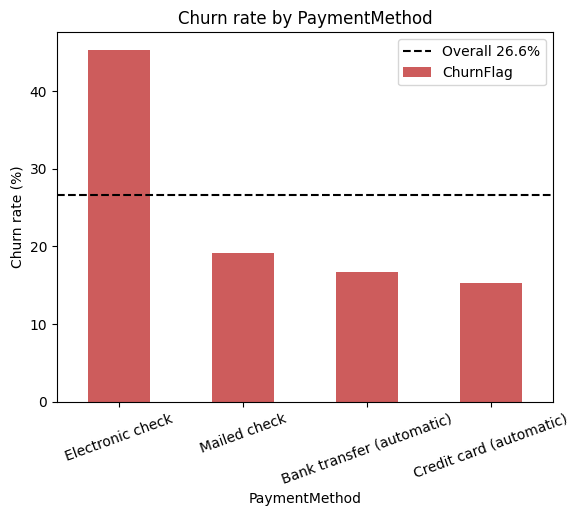

In [8]:
churn_by('PaymentMethod', rotate=20)

TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: ChurnFlag, dtype: float64


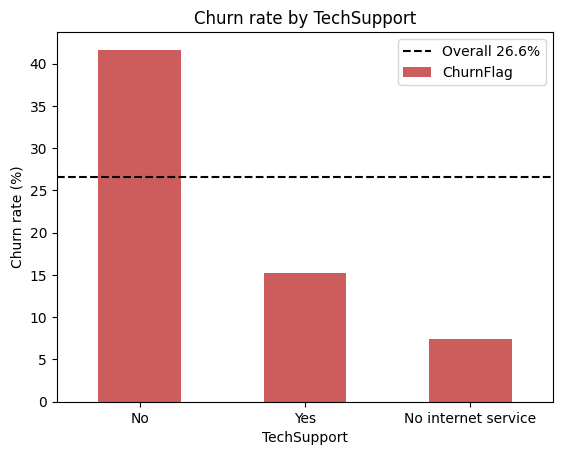

In [9]:
churn_by('TechSupport')

SeniorCitizen
Yes    41.7
No     23.7
Name: ChurnFlag, dtype: float64


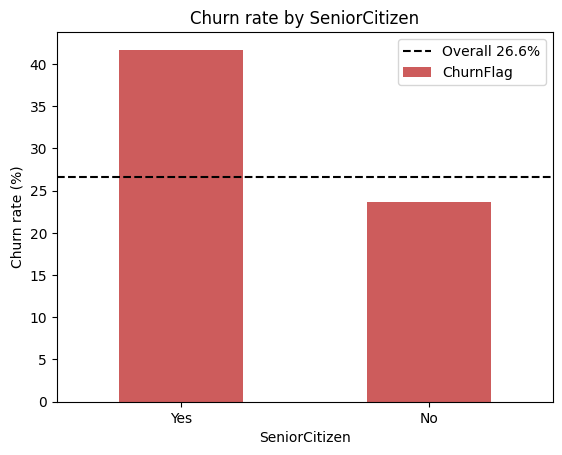

In [10]:
churn_by('SeniorCitizen')

## Step 6: Tenure and monthly charges
*Why:* new customers and expensive plans are common churn drivers. We group tenure into bands to compare.

TenureGroup
0-12 months     47.7
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5
Name: ChurnFlag, dtype: float64


/tmp/ipykernel_1276/3847381067.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df.groupby(col)['ChurnFlag'].mean() * 100).sort_values(ascending=False)


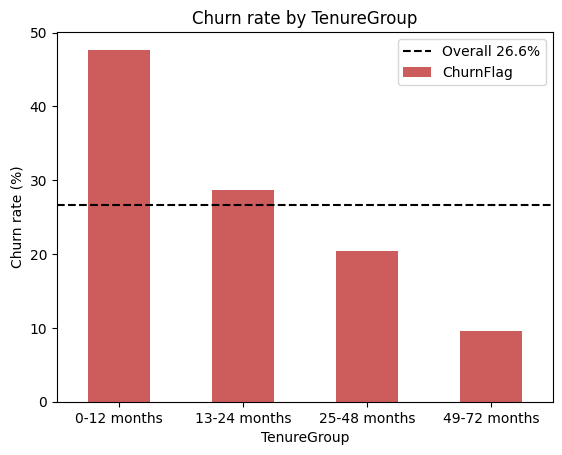

In [11]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                           labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])
churn_by('TenureGroup')

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


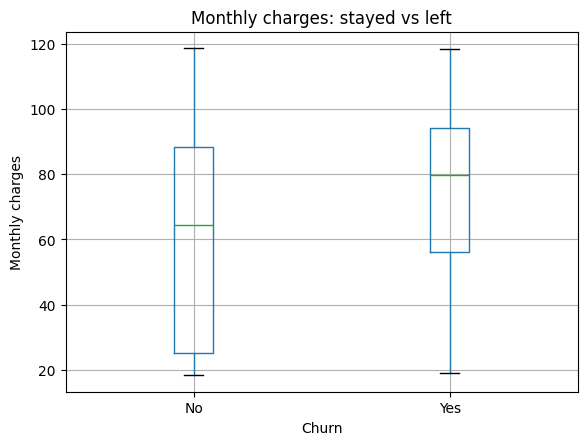

In [12]:
# Average monthly charge of customers who left vs stayed
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly charges: stayed vs left')
plt.suptitle('')
plt.ylabel('Monthly charges')
plt.show()

## Step 7: The highest-risk segment
*Why:* combining factors shows who the company should focus on first. Here: month-to-month contract, fiber optic internet, and 12 months or less of tenure.

In [13]:
risk = df[(df['Contract'] == 'Month-to-month') &
          (df['InternetService'] == 'Fiber optic') &
          (df['tenure'] <= 12)]
print('Customers in this segment:', len(risk))
print(f"Share of all customers: {len(risk) / len(df) * 100:.1f}%")
print(f"Churn rate in this segment: {risk['ChurnFlag'].mean() * 100:.1f}% (overall {overall_churn:.1f}%)")

Customers in this segment: 916
Share of all customers: 13.0%
Churn rate in this segment: 70.2% (overall 26.6%)


## Step 8: Revenue at risk
*Why:* a business cares about money. This estimates the monthly revenue lost to churned customers.

In [14]:
lost_monthly = df.loc[df['ChurnFlag'] == 1, 'MonthlyCharges'].sum()
total_monthly = df['MonthlyCharges'].sum()
print(f'Monthly revenue from customers who churned: {lost_monthly:,.0f}')
print(f'That is {lost_monthly / total_monthly * 100:.1f}% of total monthly revenue')

Monthly revenue from customers who churned: 139,131
That is 30.5% of total monthly revenue


## Step 9 (optional): Simple prediction model
A logistic regression estimates which factors push a customer toward churning. For an analyst role this is a bonus, not the main point: the business story above matters more.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = pd.get_dummies(df.drop(columns=['customerID', 'Churn', 'ChurnFlag', 'TenureGroup']), drop_first=True)
y = df['ChurnFlag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
print('Accuracy on test data:', round(accuracy_score(y_test, model.predict(X_test)), 3))

# Which features raise or lower churn risk the most
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print()
print('Features that most reduce churn:')
print(coefs.head(5).round(2))
print()
print('Features that most increase churn:')
print(coefs.tail(5).round(2))

Accuracy on test data: 0.805

Features that most reduce churn:
Contract_Two year    -1.39
Contract_One year    -0.76
OnlineSecurity_Yes   -0.35
TechSupport_Yes      -0.31
Dependents_Yes       -0.23
dtype: float64

Features that most increase churn:
PaymentMethod_Electronic check    0.39
MultipleLines_Yes                 0.39
StreamingMovies_Yes               0.39
StreamingTV_Yes                   0.42
InternetService_Fiber optic       1.24
dtype: float64


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 10: Findings and recommendations
*Fill in the numbers from your own outputs above, and keep only statements your charts support.*

**Findings**
1. Overall churn rate is ___%.
2. Customers on ___ contracts churn the most (___%), while ___ contracts churn the least (___%).
3. Churn is highest in the first ___ months of tenure.
4. Customers with ___ internet service / paying by ___ churn more than average.
5. Customers without tech support churn at ___% vs ___% with it.
6. The highest-risk segment (month-to-month + fiber optic + tenure 12 months or less) churns at ___%.

**Recommendations**
1. Offer discounts or incentives to move month-to-month customers onto 1-year or 2-year contracts.
2. Run a focused onboarding and check-in program for customers in their first year.
3. Investigate fiber optic service quality and pricing, since that group churns more.
4. Bundle tech support or online security with plans, since customers who have them churn less.
5. Target the highest-risk segment first with retention offers.

**Limitations:** the data is a single snapshot, so we show associations, not proof of cause, and the dataset is a sample from IBM, not a real company's full records.